# PCA

## 1. Read Data

In [5]:
import pca_utils

dir(pca_utils)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__']

In [6]:
import os

os.getcwd()
os.listdir()

['evaldata_cleaned.csv',
 '.DS_Store',
 'requirements.txt',
 'pca_utils.py',
 'engineered_features.csv',
 '__pycache__',
 'README.md',
 'PCA.ipynb',
 '.git',
 'gitignore.txt',
 'Feature Engineer.ipynb']

In [12]:
import pandas as pd
import numpy as np
import pca_utils

INPUT_PATH = "engineered_features.csv"  
OUTPUT_PATH = "pca_features.csv"         

df = pd.read_csv(INPUT_PATH)
print("Loaded:", df.shape)

Loaded: (256865, 40)


## 2. Define Variable Groups

In [17]:
crime_vars = [ "violent_crime_rate", "property_crime_rate", "drug_crime_rate", "other_crime_rate", ]
socio_vars = [ "poverty_rate_pct", "median_household_income", "unemployment_rate_pct", "high_school_plus_rate_pct", "college_degree_rate_pct", "median_gross_rent", "median_home_value", "uninsured_rate_pct", ]

## 3 Heatmaps before PCA

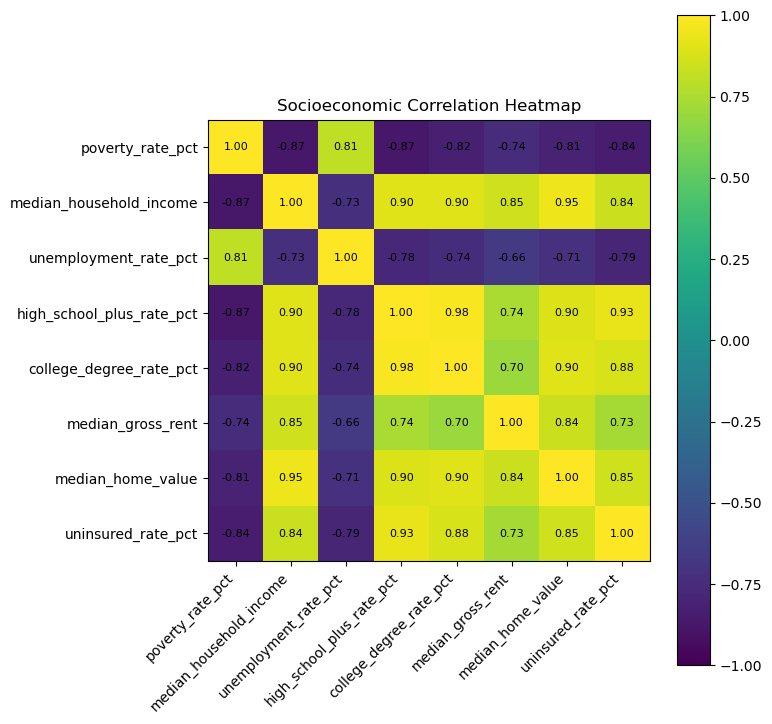

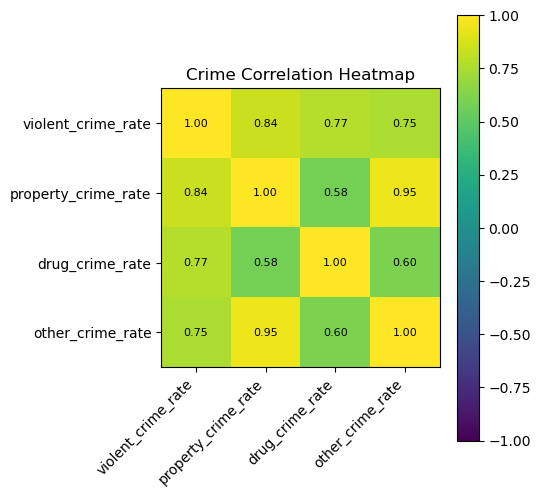

In [20]:
pca_utils.corr_heatmap(df, socio_vars, "Socioeconomic Correlation Heatmap")
pca_utils.corr_heatmap(df, crime_vars, "Crime Correlation Heatmap")

## 3. PCA

In [23]:
df = pca_utils.add_pca_index(df, socio_vars, "socio_index")
df = pca_utils.add_pca_index(df, crime_vars, "crime_index")


socio_index explained variance ratio: 0.8414640615983697
Loadings for socio_index
high_school_plus_rate_pct    0.371952
median_home_value            0.364593
college_degree_rate_pct      0.363170
median_household_income      0.362651
uninsured_rate_pct           0.357114
poverty_rate_pct            -0.354701
median_gross_rent            0.327619
unemployment_rate_pct       -0.323478
dtype: float64

crime_index explained variance ratio: 0.8177161995915785
Loadings for crime_index
property_crime_rate    0.521845
violent_crime_rate     0.515343
other_crime_rate       0.511479
drug_crime_rate        0.447760
dtype: float64



Principal Component Analysis (PCA) was applied to construct composite indices for socioeconomic conditions and crime environment.
The first principal component explained 84.1% of the variance among socioeconomic variables and 81.8% of the variance among crime variables, indicating strong correlations within each group.
The socioeconomic index loads positively on education levels, income, housing value, and rent, and negatively on poverty and unemployment rates, suggesting that higher values represent more affluent neighborhoods.
The crime index loads positively on all crime rate variables, indicating that it primarily captures overall crime intensity in the area.

## 4. Export

In [24]:
df.to_csv(OUTPUT_PATH, index=False)
print("Saved:", OUTPUT_PATH)

Saved: pca_features.csv
